In [1]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!unzip /content/drive/MyDrive/ColorDetection.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/ColorDetection/ColorsDetection/archive (2)/myntradataset/images/58138.jpg  
  inflating: /content/ColorDetection/ColorsDetection/archive (2)/myntradataset/images/58139.jpg  
  inflating: /content/ColorDetection/ColorsDetection/archive (2)/myntradataset/images/5814.jpg  
  inflating: /content/ColorDetection/ColorsDetection/archive (2)/myntradataset/images/58140.jpg  
  inflating: /content/ColorDetection/ColorsDetection/archive (2)/myntradataset/images/58141.jpg  
  inflating: /content/ColorDetection/ColorsDetection/archive (2)/myntradataset/images/58143.jpg  
  inflating: /content/ColorDetection/ColorsDetection/archive (2)/myntradataset/images/58144.jpg  
  inflating: /content/ColorDetection/ColorsDetection/archive (2)/myntradataset/images/58145.jpg  
  inflating: /content/ColorDetection/ColorsDetection/archive (2)/myntradataset/images/58146.jpg  
  inflating: /content/ColorDetection/ColorsDetection/archive (2)/myn

In [4]:
import numpy as np
np.random.seed(345)
from tensorflow.random import set_seed
set_seed(3)

In [6]:
!pip install keras_preprocessing
import shutil
from collections import defaultdict
import json
from pathlib import Path
import os
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from numpy import asarray
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.regularizers import l1_l2
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn import datasets
from sklearn import model_selection
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras_preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPooling2D, Dropout,Flatten,Dense,Activation, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam, Adamax
tf.keras.backend.clear_session()
from tensorflow.keras.callbacks import CSVLogger
import time
from datetime import datetime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.3 MB/s eta 0:00:00


In [7]:
keras.__version__, tf.__version__


('3.8.0', '2.18.0')

In [26]:
train = '/content/ColorDetection/ColorsDetection/archive/train/'
val = '/content/ColorDetection/ColorsDetection/archive/val/'
test = '/content/ColorDetection/ColorsDetection/archive/test/'
inference = '/content/ColorDetection/ColorsDetection/archive (2)/images/'
annot_err = '/content/ColorDetection/ColorsDetection/archive (1)/annotation-error.txt'

In [9]:
def count_images(dataset):
    """
    dataset: 'train/' or 'test/'
    """
    v = []
    for i in sorted(os.listdir(dataset)):
        v.append(len(os.listdir(dataset+i)))
    df = pd.DataFrame({'color': sorted(os.listdir(dataset)), 'count': v})
    return(df)

In [10]:
df = count_images(train)


In [11]:
df


,color,count
0,beige,421
1,black,406
2,blue,742
3,brown,565
4,gold,210
5,green,563
6,grey,428
7,orange,534
8,pink,483
9,purple,536


In [12]:
df['count'].min(), df['count'].mean(), df['count'].max()


(210, np.float64(484.46666666666664), 742)

In [13]:
df['count'].sum()


np.int64(7267)

In [14]:
class_subset = sorted(os.listdir(train))


In [15]:
class_subset


['beige',
 'black',
 'blue',
 'brown',
 'gold',
 'green',
 'grey',
 'orange',
 'pink',
 'purple',
 'red',
 'silver',
 'tan',
 'white',
 'yellow']

In [16]:
isize = 224


In [17]:
model_name='EfficientNetB3'
base_model=tf.keras.applications.EfficientNetB3(include_top=False, weights='imagenet',input_shape=(isize, isize, 3), pooling='max')
x=base_model.output
x=keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001 )(x)
x = Dense(256, activation='relu')(x)
x=Dropout(rate=.45, seed=123)(x)
output=Dense(len(class_subset), activation='softmax')(x)
model=Model(inputs=base_model.input, outputs=output)
model.compile(Adamax(learning_rate=.0001), loss='categorical_crossentropy', metrics=['accuracy'])

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 224, 224, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 224, 224, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 40)   │          1,080 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 40)   │            160 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 40)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 40)   │            360 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 40)   │            160 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 40)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 40)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 40)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 10)       │            410 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_expand    

 Total params: 11,187,006 (42.68 MB)

 Trainable params: 11,096,631 (42.33 MB)

 Non-trainable params: 90,375 (353.03 KB)

In [19]:
train_generator = ImageDataGenerator(
    rescale=1/255.,
    brightness_range=None,
    width_shift_range=0.5,
    rotation_range=False,
    horizontal_flip=True,
    vertical_flip=False
)

valid_generator = ImageDataGenerator(rescale=1/255.)

In [20]:
test_generator = ImageDataGenerator(rescale=1./255)


In [21]:
def flatten(l):
    return [item for sublist in l for item in sublist]

In [24]:
def dataframe_keras(sourcedir, removal_files, textdir):
    """Automatically returns a DataFrame that can be used in flow_from_dataframe method.
    sourcedir: where the data folders corresponding to each class live, for ex. 'fashion-train/'
    Each class is in a different folder.
    removal_files: indicate 'yes' if specific image files need to be removed, for instance because of annotation errors.
    textdir: directory where a textfile can be found with files to be removed.
    """

    coll_labelnames = []
    coll_idfiles = []

    for i in os.listdir(sourcedir):
        idfiles = os.listdir(os.path.join(sourcedir, i))

        labelnames = len(idfiles) * [str(i)]


        coll_labelnames.append(labelnames)
        coll_idfiles.append(idfiles)

    df = pd.DataFrame({'label': flatten(coll_labelnames), 'idfiles': flatten(coll_idfiles)})
    df['id'] = str(sourcedir) + df['label'] + '/' + df['idfiles']

    print('Raw data before removal has shape:', df.shape)

    # removes image files that are mentioned in textfile.

    if removal_files == 'yes':
        with open(textdir) as f:
            files_to_remove = f.read().splitlines()
        files_to_remove = list(filter(lambda x: 'jpg' in x, files_to_remove))
        print('Number of image files to be removed:', len(files_to_remove))
        df = df[~df['idfiles'].isin(files_to_remove)]
        print('Raw data after removal has shape:', df.shape)
    else:
        print('No images removed')

    return(df)

In [27]:
traindf = dataframe_keras(train, 'yes', annot_err)
validdf = dataframe_keras(val, 'yes', annot_err)

Raw data before removal has shape: (7267, 3)
Number of image files to be removed: 64
Raw data after removal has shape: (7202, 3)
Raw data before removal has shape: (1550, 3)
Number of image files to be removed: 64
Raw data after removal has shape: (1550, 3)


In [28]:
traindf.head()


,label,idfiles,id
0,red,b651b6501a.jpg,/content/ColorDetection/ColorsDetection/archiv...
1,red,f030f9405a.jpg,/content/ColorDetection/ColorsDetection/archiv...
2,red,8c6fe6e411.jpg,/content/ColorDetection/ColorsDetection/archiv...
3,red,b76b1e40c3.jpg,/content/ColorDetection/ColorsDetection/archiv...
4,red,7d69aef90d.jpg,/content/ColorDetection/ColorsDetection/archiv...


In [29]:
BATCH_SIZE = 32


In [30]:
traingen=train_generator.flow_from_dataframe(
    dataframe=traindf,
    directory=None,
    x_col="id",
    y_col="label",
    subset="training",
    batch_size=BATCH_SIZE,
    shuffle=True,
    class_mode="categorical",
    target_size=(isize, isize))

validgen=valid_generator.flow_from_dataframe(
    dataframe=validdf,
    directory=None,
    x_col="id",
    y_col="label",
    subset="training",
    batch_size=BATCH_SIZE,
    shuffle=True,
    class_mode="categorical",
    target_size=(isize, isize))

Found 7202 validated image filenames belonging to 15 classes.
Found 1550 validated image filenames belonging to 15 classes.


In [31]:
t1 = time.time()/60

steps_per_epoch = traingen.samples // BATCH_SIZE
val_steps = validgen.samples // BATCH_SIZE
n_epochs = 80

csv_logger = CSVLogger('training.log', separator=',', append=False)

checkpointer = ModelCheckpoint(filepath='EFN-model.best.h5',
                               verbose=1,
                               save_best_only=True)

early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True,
                           mode='min')

history = model.fit(traingen,
                    epochs=n_epochs,
                    steps_per_epoch=steps_per_epoch,
                    validation_data=validgen,
                    validation_steps=val_steps,
                    callbacks=[early_stop, checkpointer, csv_logger],
                    verbose=True,
                    shuffle = True
                    )

t2 = time.time()/60
print("Duration:", t2-t1)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.1047 - loss: 3.4962
Epoch 1: val_loss improved from inf to 3.95826, saving model to EFN-model.best.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 302s 802ms/step - accuracy: 0.1050 - loss: 3.4945 - val_accuracy: 0.0768 - val_loss: 3.9583
Epoch 2/80
  1/225 ━━━━━━━━━━━━━━━━━━━━ 1:02 277ms/step - accuracy: 0.4062 - loss: 1.9773

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 3.95826 to 3.94641, saving model to EFN-model.best.h5


...

225/225 ━━━━━━━━━━━━━━━━━━━━ 144s 615ms/step - accuracy: 0.7827 - loss: 0.6326 - val_accuracy: 0.8281 - val_loss: 0.4751
Epoch 36/80
  1/225 ━━━━━━━━━━━━━━━━━━━━ 54s 245ms/step - accuracy: 0.8125 - loss: 0.6199
Epoch 36: val_loss did not improve from 0.47506
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8125 - loss: 0.6199 - val_accuracy: 0.8288 - val_loss: 0.4753
Epoch 37/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.7854 - loss: 0.6276
Epoch 37: val_loss did not improve from 0.47506
225/225 ━━━━━━━━━━━━━━━━━━━━ 174s 513ms/step - accuracy: 0.7854 - loss: 0.6276 - val_accuracy: 0.8255 - val_loss: 0.4768
Epoch 38/80
  1/225 ━━━━━━━━━━━━━━━━━━━━ 54s 243ms/step - accuracy: 0.7812 - loss: 0.6129
Epoch 38: val_loss did not improve from 0.47506
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7812 - loss: 0.6129 - val_accuracy: 0.8255 - val_loss: 0.4756
Epoch 39/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.7942 - loss: 0.6108
Epoch 39: val_loss i

225/225 ━━━━━━━━━━━━━━━━━━━━ 116s 516ms/step - accuracy: 0.7942 - loss: 0.6108 - val_accuracy: 0.8242 - val_loss: 0.4747
Epoch 40/80
  1/225 ━━━━━━━━━━━━━━━━━━━━ 54s 242ms/step - accuracy: 0.9375 - loss: 0.2574
Epoch 40: val_loss did not improve from 0.47472
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9375 - loss: 0.2574 - val_accuracy: 0.8223 - val_loss: 0.4761
Epoch 41/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.7921 - loss: 0.6198
Epoch 41: val_loss did not improve from 0.47472
225/225 ━━━━━━━━━━━━━━━━━━━━ 142s 631ms/step - accuracy: 0.7921 - loss: 0.6199 - val_accuracy: 0.8268 - val_loss: 0.4922
Epoch 42/80
  1/225 ━━━━━━━━━━━━━━━━━━━━ 52s 232ms/step - accuracy: 0.7812 - loss: 0.6460
Epoch 42: val_loss did not improve from 0.47472
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7812 - loss: 0.6460 - val_accuracy: 0.8242 - val_loss: 0.4952
Epoch 43/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.7940 - loss: 0.6038
Epoch 43: val_loss i

225/225 ━━━━━━━━━━━━━━━━━━━━ 204s 662ms/step - accuracy: 0.7940 - loss: 0.6038 - val_accuracy: 0.8242 - val_loss: 0.4678
Epoch 44/80
  1/225 ━━━━━━━━━━━━━━━━━━━━ 1:08 306ms/step - accuracy: 0.7500 - loss: 0.6511
Epoch 44: val_loss did not improve from 0.46778
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7500 - loss: 0.6511 - val_accuracy: 0.8236 - val_loss: 0.4680
Epoch 45/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.8005 - loss: 0.5897
Epoch 45: val_loss did not improve from 0.46778
225/225 ━━━━━━━━━━━━━━━━━━━━ 160s 514ms/step - accuracy: 0.8005 - loss: 0.5897 - val_accuracy: 0.8372 - val_loss: 0.4699
Epoch 46/80
  1/225 ━━━━━━━━━━━━━━━━━━━━ 54s 242ms/step - accuracy: 0.8125 - loss: 0.4620
Epoch 46: val_loss did not improve from 0.46778
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8125 - loss: 0.4620 - val_accuracy: 0.8353 - val_loss: 0.4720
Epoch 47/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.7921 - loss: 0.6162
Epoch 47: val_loss 

225/225 ━━━━━━━━━━━━━━━━━━━━ 143s 539ms/step - accuracy: 0.7922 - loss: 0.6160 - val_accuracy: 0.8457 - val_loss: 0.4403
Epoch 48/80
  1/225 ━━━━━━━━━━━━━━━━━━━━ 55s 246ms/step - accuracy: 0.7812 - loss: 0.5274
Epoch 48: val_loss improved from 0.44025 to 0.43465, saving model to EFN-model.best.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7812 - loss: 0.5274 - val_accuracy: 0.8483 - val_loss: 0.4347
Epoch 49/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.8061 - loss: 0.5646
Epoch 49: val_loss did not improve from 0.43465
225/225 ━━━━━━━━━━━━━━━━━━━━ 140s 560ms/step - accuracy: 0.8061 - loss: 0.5645 - val_accuracy: 0.8424 - val_loss: 0.4372
Epoch 50/80
  1/225 ━━━━━━━━━━━━━━━━━━━━ 53s 241ms/step - accuracy: 0.8438 - loss: 0.3805
Epoch 50: val_loss did not improve from 0.43465
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8438 - loss: 0.3805 - val_accuracy: 0.8398 - val_loss: 0.4414
Epoch 51/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.8200 - loss: 0.5457
Epoch 51: val_loss did not improve from 0.43465
225/225 ━━━━━━━━━━━━━━━━━━━━ 124s 502ms/step - accuracy: 0.8200 - loss: 0.5458 - val_accuracy: 0.8405 - val_loss: 0.4448
Epoch 52/80
  1/225 ━━━━━━━━━━━━━━━━━━━━ 54s 245ms/step - accuracy: 0.9375 - loss: 0.3057
Epoch 52: val_loss d

In [32]:
model.save_weights("model_weights.weights.h5")

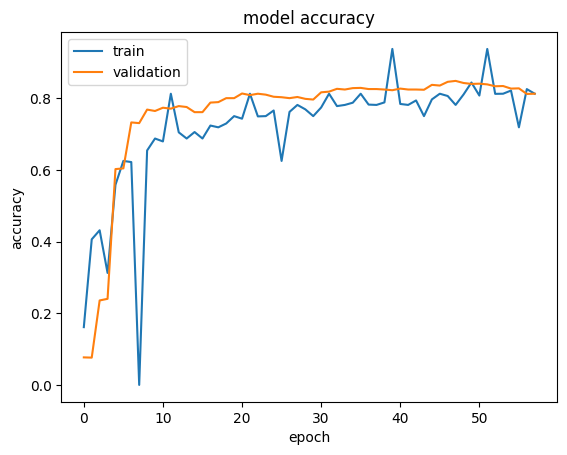

In [33]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [34]:
class_subset = sorted(os.listdir(test))


In [35]:
test_generator = ImageDataGenerator(rescale=1./255)


In [36]:
testgen = test_generator.flow_from_directory(test,
                                             target_size=(isize, isize),
                                             batch_size=1,
                                             class_mode=None,
                                             classes=class_subset,
                                             shuffle=False
                                             )

Found 1556 images belonging to 15 classes.


In [37]:
model_predict = model.predict(testgen)


1556/1556 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step


In [38]:
model_predict.shape


(1556, 15)

In [39]:
df_testprediction = pd.DataFrame(model_predict, index=testgen.filenames, columns=class_subset)

In [40]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)
df_testprediction

,beige,black,blue,brown,gold,green,grey,orange,pink,purple,red,silver,tan,white,yellow
beige/02e37c0e56.jpg,0.1708,0.0096,0.0030,0.1583,0.0056,0.0219,0.1846,0.0016,0.0036,0.0010,0.0141,0.1606,0.2546,0.0048,0.0060
beige/05aeb6ddec.jpg,0.1074,0.0042,0.0040,0.7623,0.0113,0.0007,0.0111,0.0000,0.0001,0.0013,0.0008,0.0037,0.0924,0.0005,0.0003
beige/0b01008bee.jpg,0.5178,0.0004,0.0001,0.0384,0.0032,0.0005,0.0005,0.0000,0.0030,0.0004,0.0007,0.0034,0.4256,0.0056,0.0003
beige/0c3bb456ee.jpg,0.4312,0.0026,0.0010,0.0110,0.0126,0.0019,0.0096,0.0021,0.0089,0.0014,0.0032,0.1067,0.2694,0.1228,0.0157
beige/0e491569c8.jpg,0.2953,0.0006,0.0001,0.0302,0.0200,0.0013,0.0073,0.0002,0.0020,0.0004,0.0006,0.0044,0.6329,0.0036,0.0011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
yellow/fd1da2f797.jpg,0.0011,0.0000,0.0001,0.0003,0.0308,0.0002,0.0002,0.0010,0.0001,0.0000,0.0000,0.0001,0.0011,0.0001,0.9648
yellow/fd3d2525fb.jpg,0.0000,0.0000,0.0000,0.0000,0.0008,0.0000,0.0000,0.0006,0.0000,0.0000,0.0001,0.0000,0.0000,0.0002,0.9981
yellow/feacf53e9e.jpg,0.0029,0.0004,0.0013,0.0978,0.5620,0.0629,0.0016,0.0005,0.0002,0.0049,0.0003,0.0007,0.0050,0.0006,0.2589
yellow/feeded3e6e.jpg,0.0010,0.0001,0.0002,0.0005,0.9484,0.0017,0.0003,0.0003,0.0000,0.0003,0.0001,0.0001,0.0004,0.0001,0.0466


In [41]:
predicted_classes = np.argmax(model.predict(testgen), axis=-1) #model.predict_classes(testgen). Argmax returns indices of max values
class_indices = traingen.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())
true_classes = testgen.classes

1556/1556 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step


In [42]:
len(predicted_classes)


1556

In [43]:
def display_results(y_true, y_preds, class_labels):

    results = pd.DataFrame(precision_recall_fscore_support(y_true, y_preds),
                           columns=class_labels).T

    results.rename(columns={0: 'Precision', 1: 'Recall',
                            2: 'F-Score', 3: 'Support'}, inplace=True)

    results.sort_values(by='F-Score', ascending=False, inplace=True)
    global_acc = accuracy_score(y_true, y_preds)

    print("Overall Categorical Accuracy: {:.2f}%".format(global_acc*100))
    return results

def plot_predictions(y_true, y_preds, test_generator, class_indices):

    fig = plt.figure(figsize=(20, 10))
    for i, idx in enumerate(np.random.choice(test_generator.samples, size=20, replace=False)):
        ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(np.squeeze(test_generator[idx]))
        pred_idx = y_preds[idx]
        true_idx = y_true[idx]

        plt.tight_layout()
        ax.set_title("{}\n({})".format(class_indices[pred_idx], class_indices[true_idx]), color=("green" if pred_idx == true_idx else "red"))
    fig.savefig('testgallery.png')

In [44]:
display_results(true_classes, predicted_classes, class_indices.values())


Overall Categorical Accuracy: 83.16%


,Precision,Recall,F-Score,Support
green,0.9440,0.9752,0.9593,121.0000
purple,0.9565,0.9565,0.9565,115.0000
blue,0.9615,0.9434,0.9524,159.0000
yellow,0.9744,0.9194,0.9461,124.0000
orange,0.9286,0.9123,0.9204,114.0000
red,0.8667,0.9559,0.9091,136.0000
pink,0.9570,0.8641,0.9082,103.0000
black,0.8444,0.8736,0.8588,87.0000
white,0.8000,0.8837,0.8398,86.0000
brown,0.7803,0.8512,0.8142,121.0000


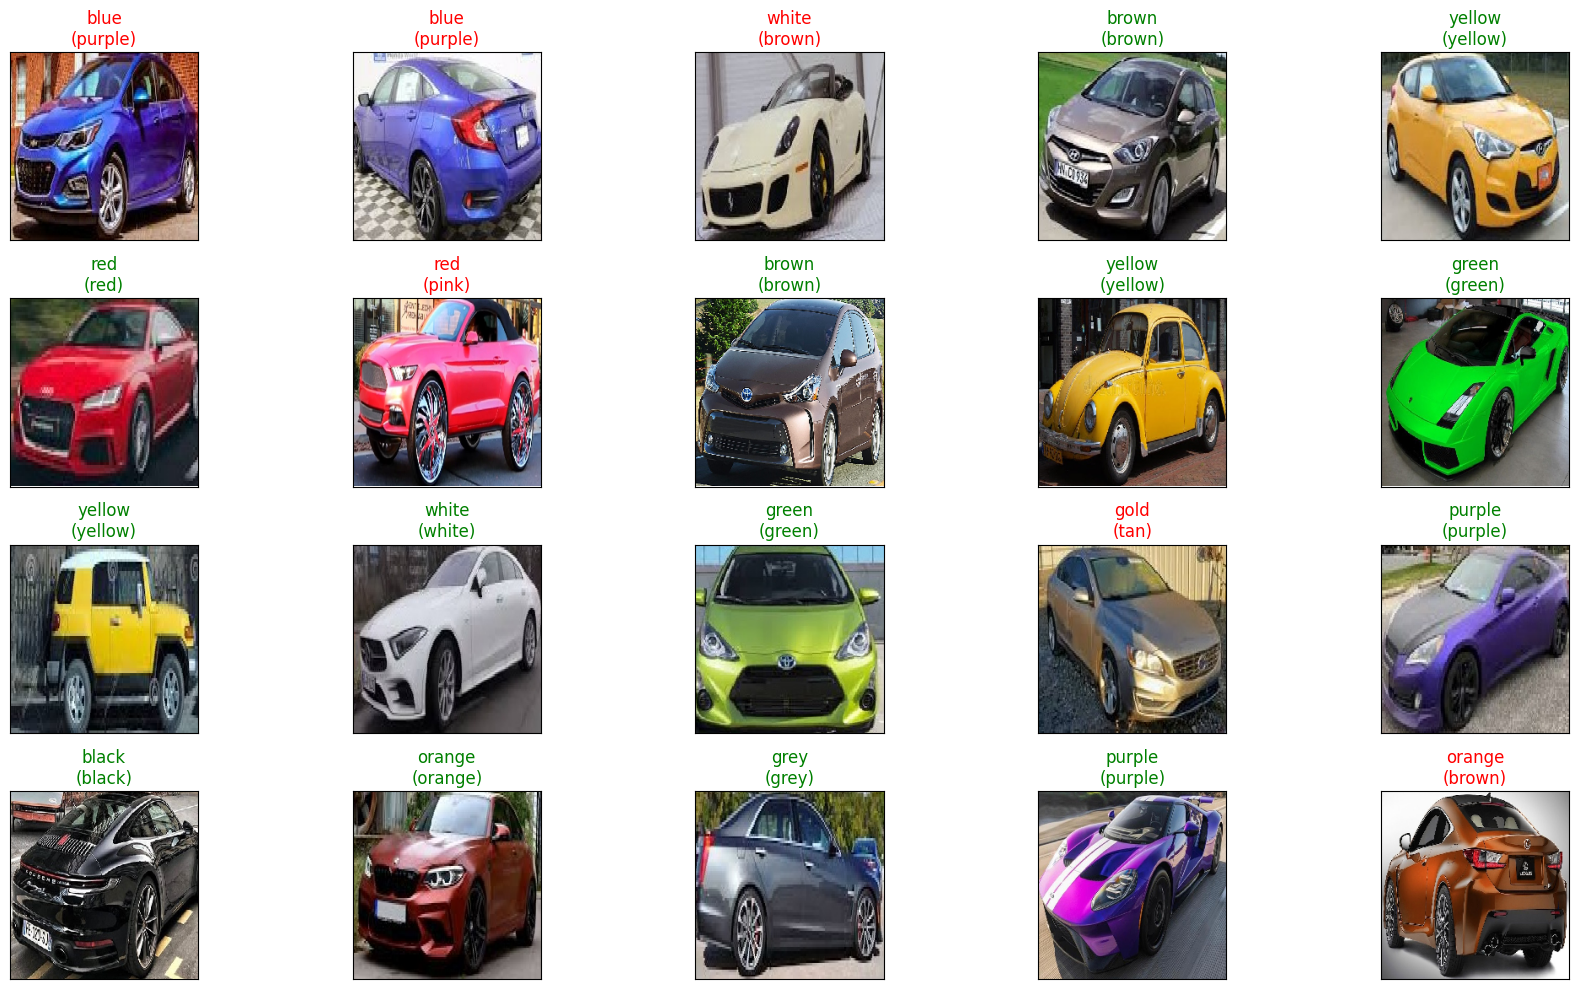

In [45]:
plot_predictions(true_classes, predicted_classes, testgen, class_indices)


In [46]:
pd.DataFrame(confusion_matrix(true_classes, predicted_classes), index=list(class_indices.values()), columns=list(class_indices.values()) )

,beige,black,blue,brown,gold,green,grey,orange,pink,purple,red,silver,tan,white,yellow
beige,37,0,0,8,1,0,1,0,0,0,0,3,38,1,1
black,0,76,1,4,0,0,6,0,0,0,0,0,0,0,0
blue,0,2,150,0,0,1,1,0,0,3,0,0,1,1,0
brown,6,2,0,103,4,0,2,1,0,0,0,0,2,1,0
gold,6,2,0,10,20,0,0,1,2,0,0,0,3,0,1
green,0,0,1,0,0,118,1,0,0,0,0,0,1,0,0
grey,0,7,1,2,0,2,69,0,0,0,0,10,0,1,0
orange,0,0,0,2,0,0,0,104,0,0,7,0,0,0,1
pink,0,0,0,0,0,0,0,0,89,2,12,0,0,0,0
purple,0,0,3,0,0,0,0,0,1,110,1,0,0,0,0


In [47]:
def color_tag(sourcedir, imin, isize, thr):
    """
    Displays dominant colors beyond a given threshold.
    sourcedir: directory where image can be found, for ex.: '/home/administrateur/Documents/RR/colors/fashion-train/purple'
    imin : image input, for ex 'blue-car.jpg'
    isize: input image size, for ex. 224
    thr: chosen threshold value
    """

    image = tf.keras.preprocessing.image.load_img(os.path.join(sourcedir, imin), target_size=(isize, isize))
    data = asarray(image)
    ndata = np.expand_dims(data, axis=0)
    y_prob = model.predict(ndata/255)
    y_prob.argmax(axis=-1)

    print('color', [sorted(os.listdir(train))[i] for i in np.where(np.ravel(y_prob)>thr)[0]])
    print('values', [np.ravel(y_prob)[i] for i in list(np.where(np.ravel(y_prob)>thr)[0])])

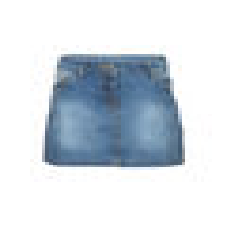

In [50]:
tf.keras.preprocessing.image.load_img(os.path.join(inference, '10001.jpg'), target_size=(227, 227))


In [51]:
color_tag(inference, '10001.jpg', isize, 0.1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
color ['black', 'blue', 'grey', 'tan']
values [np.float32(0.11298398), np.float32(0.21535943), np.float32(0.21859793), np.float32(0.16887684)]


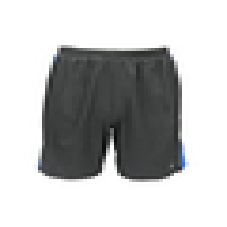

In [52]:
tf.keras.preprocessing.image.load_img(os.path.join(inference, '10004.jpg'), target_size=(227, 227))


In [53]:
color_tag(inference, '10004.jpg', isize, 0.1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
color ['black', 'grey', 'pink']
values [np.float32(0.15034586), np.float32(0.12843412), np.float32(0.22816484)]


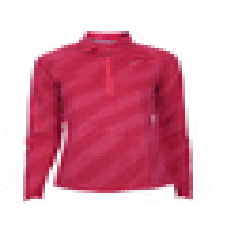

In [54]:
tf.keras.preprocessing.image.load_img(os.path.join(inference, '10025.jpg'), target_size=(227, 227))


In [55]:
color_tag(inference, '10025.jpg', isize, 0.1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
color ['pink']
values [np.float32(0.8083956)]


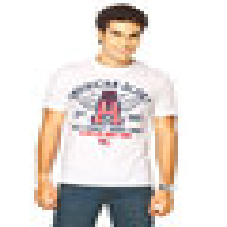

In [57]:
tf.keras.preprocessing.image.load_img(os.path.join(inference, '10015.jpg'), target_size=(227, 227))


In [58]:
color_tag(inference, '10015.jpg', isize, 0.1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
color ['black', 'grey', 'silver', 'white']
values [np.float32(0.11342275), np.float32(0.1561064), np.float32(0.35670605), np.float32(0.23506083)]


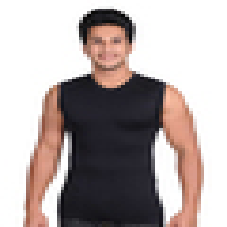

In [61]:
tf.keras.preprocessing.image.load_img(os.path.join(inference, '1798.jpg'), target_size=(227, 227))


In [62]:
color_tag(inference, '1798.jpg', isize, 0.1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
color ['black', 'pink']
values [np.float32(0.11055035), np.float32(0.57746786)]


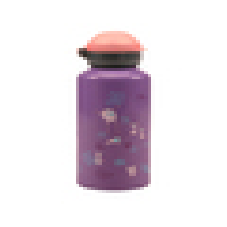

In [63]:
tf.keras.preprocessing.image.load_img(os.path.join(inference, '1808.jpg'), target_size=(227, 227))


In [65]:
color_tag(inference, '1808.jpg', isize, 0.1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
color ['pink', 'purple', 'red']
values [np.float32(0.21368621), np.float32(0.33698985), np.float32(0.18013132)]


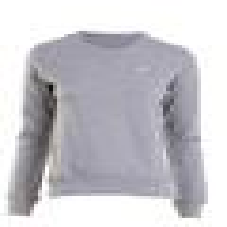

In [68]:
tf.keras.preprocessing.image.load_img(os.path.join(inference, '2268.jpg'), target_size=(227, 227))


In [69]:
color_tag(inference, '2268.jpg', isize, 0.1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
color ['black', 'grey']
values [np.float32(0.26710013), np.float32(0.2949858)]
